# **Exercise Regression**

**Authors:** Sek Huen Leung, Kadri Kalamäe

**Date:** 02.09.2026


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
import gdown

gdown.download(
    id="1cmyVKxlvZlkD7CNsdiXBINsZQjwtsy7M",
    output="pollution_cleaneddata.csv",
    quiet=True
)

'pollution_cleaneddata.csv'

In [2]:
# Local simple regression
def loess(y_,x_,k,x0_, plot=True):
  '''
  Inputs:
  y_ (vector of observations of the response variable)
  x_ (vector of observations of the predictor)
  k (number of neighboring points to include in each local regression)
  x0_ (vector of values for which a prediction is going to be made)
  plot (if True, calls loess_plot() for each x0)

  Outputs:
  pred (predicted values)
  se_ (std. error of expected value)
  '''
  # -- convert inputs to numpy arrays of floats, just in case
  y_ = np.asarray(y_, dtype=float)
  x_ = np.asarray(x_, dtype=float)
  x0_ = np.asarray(x0_, dtype=float)

  pred = []
  se_ = []

  # selected predictor x0
  for x0 in x0_:

    # -- choose k nearest neighbours of x0
    distance = np.abs(x_ - x0)
    index = np.argsort(distance)[:k]
    x_local = x_[index]
    y_local = y_[index]
    r_local = distance[index]

    # -- assign a weight to each neighbour by how close it is to x0
    # we choose: (1 - r/r_max)^2
    # weight 1 for r=0 (right at x0)
    # weight 0 for the farthest of the k neighbours (r=r_max)
    # with this design actually k-1 points influence the fit
    weights = (1-r_local/np.max(r_local))**2

    # -- fit a weighted simple OSL
    # weighted means
    x_bar = np.sum(weights * x_local) / np.sum(weights)
    y_bar = np.sum(weights * y_local) / np.sum(weights)

    # weighted slope
    beta1 = (
            np.sum(weights * (x_local - x_bar) * (y_local - y_bar))
             /
            np.sum(weights * (x_local - x_bar)**2)
        )

    # intercept
    beta0 = y_bar - beta1 * x_bar

    # -- prediction at x0
    y_hat = beta0 + beta1 * x0
    pred.append(y_hat)

    # -- standard error of predicted value
    # let's use approach without weighting
    fitted = beta0 + beta1 * x_local
    residual = y_local - fitted
    df = k-2 # 2 parameters estimated
    sigma2 = np.sum(residual**2) / df
    x_bar = np.mean(x_local) # unweighted
    Sxx = np.sum((x_local - x_bar)**2) # unweighted

    se = np.sqrt(sigma2 * (1/k + ((x0 - x_bar)**2) / Sxx))
    se_.append(se)

    #plots
    if plot:
      loess_plot(y_, x_, y_hat, x0, index, beta0, beta1)
  return pred, se_

In [3]:
# plot function

def loess_plot(y_,x_,y_hat,x0,index,beta0,beta1):
    # selected local data
    x_local = x_[index]
    y_local = y_[index]

    # local regression line
    x_line = np.linspace(
        np.min(x_local),
        np.max(x_local),
        100
    )

    y_line = beta0 + beta1 * x_line

    # plot
    plt.figure()

    # all observations: grey circles
    plt.scatter(
        x_,
        y_,
        facecolors="none",
        edgecolors="grey",
        s=50,
    )

    # selected k nearest points: orange circles
    plt.scatter(
        x_local,
        y_local,
        facecolors="none",
        edgecolors="orange",
        s=60,
        linewidth=1.5,
    )

    # local linear regression: red line
    plt.plot(
        x_line,
        y_line,
        color="red",
        linewidth=2,
    )

    # vertical orange line locating x0
    plt.plot(
    [x0, x0],
    [plt.ylim()[0], y_hat],
    color="orange",
    linewidth=1.5
    )

    # prediction point: red dot
    plt.scatter(
        x0,
        y_hat,
        color="red",
        s=80,
        zorder=5,

    )

    # labels
    plt.xlabel("POOR")
    plt.ylabel("MORT")

    plt.title(
        f"Local regression at x0 = {x0:.1f}"
    )

    plt.show()
    return

In [4]:
# load data file
data = pd.read_csv("pollution_cleaneddata.csv")
# response
y_ = data["MORT"]
# input variable
x_ = data["POOR"]
# number of nearest points
# we choose 15 because this seems reasonably small and large at the same time (keeping in mind the total sample size being 60)
k = 15
# predictors
x0_ = np.array([10., 18., 25.])

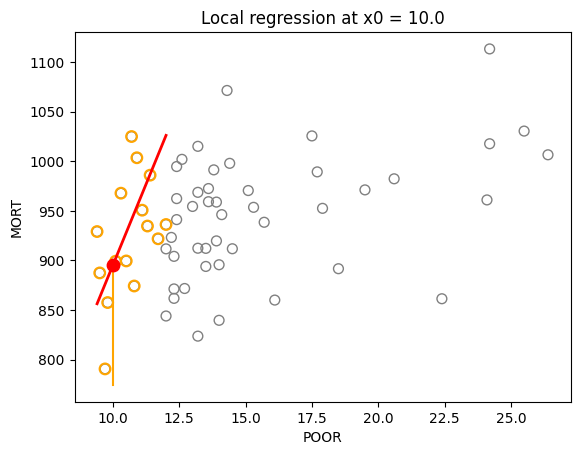

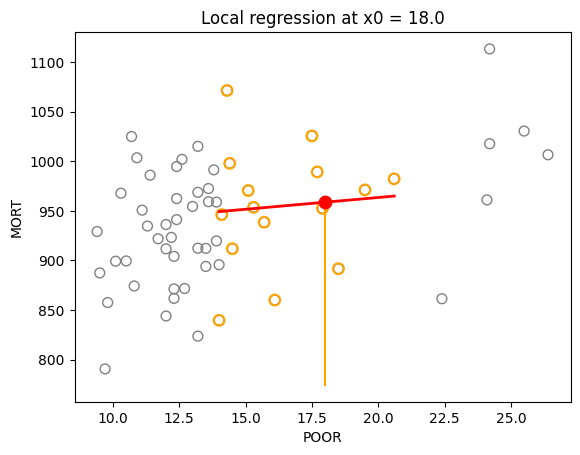

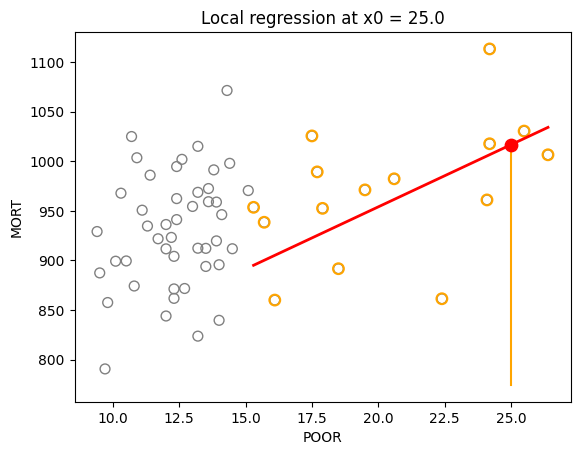

   x0     Prediction      SE
--------------------------------
  10.0      895.545     20.321
  18.0      958.716     20.673
  25.0     1016.593     26.888


In [5]:
# run the function
y_hat_, se_, = loess(y_, x_, k, x0_)
# print result
print("   x0     Prediction      SE")
print("--------------------------------")

for x0, yhat, se in zip(x0_, y_hat_, se_):
    print(f"{x0:6.1f}   {yhat:10.3f}   {se:8.3f}")